# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [186]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [187]:
nutricion = pd.read_csv("data/nndb_flat.csv")

In [188]:
nutricion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


In [189]:
nutricion.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [190]:
corr = nutricion.corr(numeric_only=True)

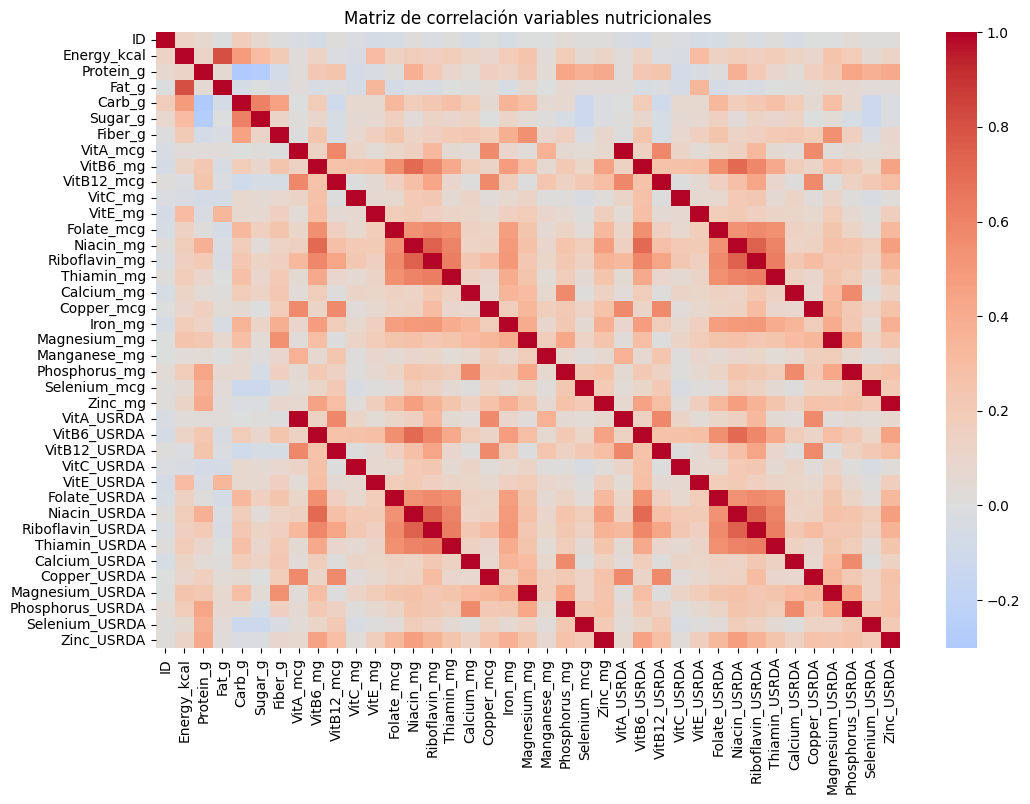

In [191]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación variables nutricionales")
plt.show()

Las columnas de USRDA parecen que derivan de las columnas de las variables nutricionales "reales" y esto duplica información, multicolinealidad. Lo mejor es borrarlas.

### Variables no numéricas
Elimina las variables de texto del dataset

In [192]:
nutricion_num = nutricion.select_dtypes(include=["number"])

Eliminamos también USRDA

In [193]:
nutricion_num = nutricion_num.loc[:, ~nutricion_num.columns.str.contains("USRDA")]

También ID

In [194]:
nutricion_num = nutricion_num.drop(columns=["ID"])

In [195]:
nutricion_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy_kcal    8618 non-null   float64
 1   Protein_g      8618 non-null   float64
 2   Fat_g          8618 non-null   float64
 3   Carb_g         8618 non-null   float64
 4   Sugar_g        8618 non-null   float64
 5   Fiber_g        8618 non-null   float64
 6   VitA_mcg       8618 non-null   float64
 7   VitB6_mg       8618 non-null   float64
 8   VitB12_mcg     8618 non-null   float64
 9   VitC_mg        8618 non-null   float64
 10  VitE_mg        8618 non-null   float64
 11  Folate_mcg     8618 non-null   float64
 12  Niacin_mg      8618 non-null   float64
 13  Riboflavin_mg  8618 non-null   float64
 14  Thiamin_mg     8618 non-null   float64
 15  Calcium_mg     8618 non-null   float64
 16  Copper_mcg     8618 non-null   float64
 17  Iron_mg        8618 non-null   float64
 18  Magnesiu

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [196]:
nutricion_log = nutricion_num.copy()
nutricion_log = np.log1p(nutricion_log) #log no sirve porque transforma los 0 en infinitos

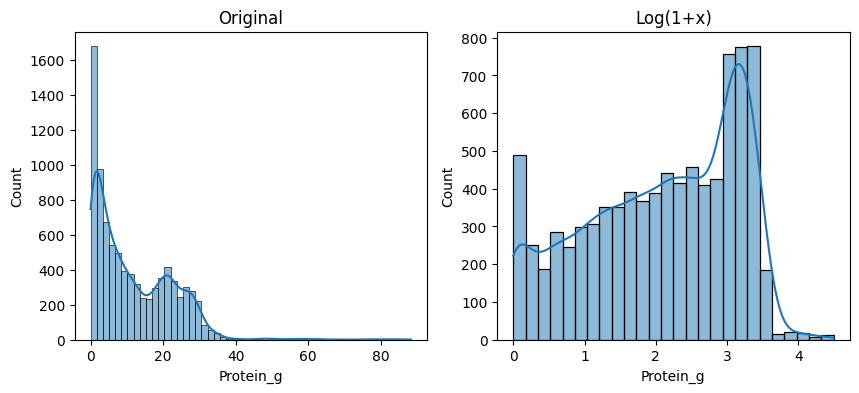

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(nutricion_num["Protein_g"], ax=axes[0], kde=True)
axes[0].set_title("Original")

sns.histplot(nutricion_log["Protein_g"], ax=axes[1], kde=True)
axes[1].set_title("Log(1+x)")

plt.show()


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [198]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(nutricion_log)

In [199]:
X_scaled.mean().round(6)

np.float64(-0.0)

In [200]:
X_scaled.std().round(6)

np.float64(1.0)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [201]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [202]:
X_pca.shape

(8618, 23)

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

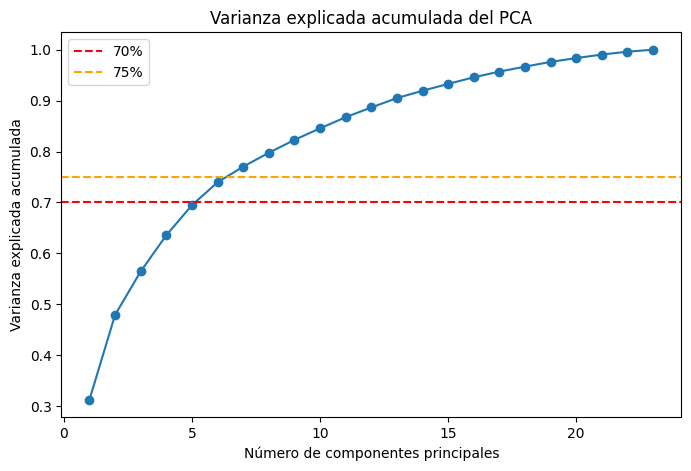

In [203]:
var_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(var_acumulada) + 1),
    var_acumulada,
    marker="o"
)
plt.axhline(0.7, color="red", linestyle="--", label="70%")
plt.axhline(0.75, color="orange", linestyle="--", label="75%")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada del PCA")
plt.legend()
plt.show()

Me quedaría con 6 componentes principales.

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [204]:
pca_red = PCA(n_components=6)
X_pca_red = pca_red.fit_transform(X_scaled)

In [205]:
nutricion_pca = pd.DataFrame(
    X_pca_red,
    columns=[f"PC{i+1}" for i in range(6)],
    index=nutricion_log.index
)

In [206]:
nutricion_pca.shape

(8618, 6)

In [207]:
nutricion_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [208]:
nutricion_pca_fg = nutricion_pca.copy()
nutricion_pca_fg["FoodGroup"] = nutricion["FoodGroup"]

In [209]:
pc_means = nutricion_pca_fg.groupby("FoodGroup").mean()

In [210]:
top3_por_pc = {}

for pc in pc_means.columns:
    top3_por_pc[pc] = pc_means[pc].sort_values(ascending=False).head(3)

top3_por_pc

{'PC1': FoodGroup
 Breakfast Cereals        4.020261
 Nut and Seed Products    3.120684
 Spices and Herbs         2.562117
 Name: PC1, dtype: float64,
 'PC2': FoodGroup
 Spices and Herbs         3.647736
 Breakfast Cereals        2.748076
 Nut and Seed Products    2.267573
 Name: PC2, dtype: float64,
 'PC3': FoodGroup
 Fats and Oils            2.333724
 Baked Products           1.727793
 Nut and Seed Products    1.241486
 Name: PC3, dtype: float64,
 'PC4': FoodGroup
 Breakfast Cereals    2.265027
 Fats and Oils        1.045026
 Beverages            0.545486
 Name: PC4, dtype: float64,
 'PC5': FoodGroup
 Fats and Oils             2.634166
 Dairy and Egg Products    1.555680
 Baby Foods                0.929960
 Name: PC5, dtype: float64,
 'PC6': FoodGroup
 Fats and Oils            2.054032
 Nut and Seed Products    1.762298
 Spices and Herbs         1.461075
 Name: PC6, dtype: float64}